In [1]:

# Importation des packages nécessaires et explication de leur utilité en commentaire

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import joblib




In [2]:
#Chargement des données

df = pd.read_csv("/content/drive/MyDrive/GOMYCODE/PROJET REBGRESSION LINEAIRE/archive/train_u6lujuX_CVtuZ9i.csv")

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
#Valeur manquante par colonne
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [6]:
#Dimensions du dataset

print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

Nombre de lignes : 614
Nombre de colonnes : 13


In [7]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [8]:
#Ligne dupliquée

df.duplicated().sum()

np.int64(0)

In [9]:
#Compter les valeurs manquantes par colonne

print("Colonne avec Valeurs manquantes")
nb_val_manq = df.isnull().sum()
col_val_manq = nb_val_manq[nb_val_manq > 0]
col_val_manq

Colonne avec Valeurs manquantes


,0
Gender,13
Married,3
Dependents,15
Self_Employed,32
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [10]:
# Valeurs aberrantes

# Passons maintenant aux valeurs aberrantes dans les colonnes numériques de mes données

# Initialiser une liste pour stocker les noms de colonnes avec des valeurs aberrantes

colonnes_aberrantes = []

def valeurs_aberrantes(df, col_numeriques):
    # Définir le seuil pour identifier les valeurs aberrantes en fonction du score Z
    seuil_z = 3
    # Boucle à travers chaque colonne numérique
    for colonne in col_numeriques:
        valeur_aberrante = []
        # Calculer la moyenne et l'écart-type de la colonne actuelle
        moyenne = df[colonne].mean()
        ecart_type = df[colonne].std()

        # Calculer les scores Z pour la colonne actuelle
        scores_z = (df[colonne] - moyenne) / ecart_type

        # Identifier les valeurs aberrantes pour la colonne actuelle
        valeurs_aberrantes = df[abs(scores_z) > seuil_z]

        # Afficher les valeurs aberrantes pour la colonne actuelle
        if not valeurs_aberrantes.empty:
             colonnes_aberrantes.append(colonne)
             print(f"Voici les valeurs aberrantes dans la colonne '{colonne}' avec zscore = 3 :")
             for index, valeur in valeurs_aberrantes[colonne].items():
                valeur_aberrante.append(valeur)
                nombre_valeur_aberrante = len(valeur_aberrante)
                pourcentage_valeur_aberrante = (nombre_valeur_aberrante / len(df)) * 100
                print(f"Ligne: {index}, Valeur: {valeur}")
                print(f"Le nombre de valeurs aberrantes de la colonne {colonne} est {nombre_valeur_aberrante}")
                print(f"Le pourcentage de valeurs aberrantes de la colonne {colonne} est {pourcentage_valeur_aberrante:.2f}%")
                print()


    print(f"\nIl y a {len(colonnes_aberrantes)} colonnes avec des valeurs aberrantes : {colonnes_aberrantes}")

In [11]:
# Création de la liste des noms de colonne numériques
col_numeriques = list(df.select_dtypes(include=['number']).columns)
col_numeriques

['ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History']

In [12]:
valeurs_aberrantes(df, col_numeriques)

Voici les valeurs aberrantes dans la colonne 'ApplicantIncome' avec zscore = 3 :
Ligne: 126, Valeur: 23803
Le nombre de valeurs aberrantes de la colonne ApplicantIncome est 1
Le pourcentage de valeurs aberrantes de la colonne ApplicantIncome est 0.16%

Ligne: 155, Valeur: 39999
Le nombre de valeurs aberrantes de la colonne ApplicantIncome est 2
Le pourcentage de valeurs aberrantes de la colonne ApplicantIncome est 0.33%

Ligne: 171, Valeur: 51763
Le nombre de valeurs aberrantes de la colonne ApplicantIncome est 3
Le pourcentage de valeurs aberrantes de la colonne ApplicantIncome est 0.49%

Ligne: 183, Valeur: 33846
Le nombre de valeurs aberrantes de la colonne ApplicantIncome est 4
Le pourcentage de valeurs aberrantes de la colonne ApplicantIncome est 0.65%

Ligne: 185, Valeur: 39147
Le nombre de valeurs aberrantes de la colonne ApplicantIncome est 5
Le pourcentage de valeurs aberrantes de la colonne ApplicantIncome est 0.81%

Ligne: 333, Valeur: 63337
Le nombre de valeurs aberrantes d

In [13]:
# Valeurs atypiques (texte mal écrit)

for colonne in df.select_dtypes(include=['object']).columns:
    print(f"Valeurs identifiées dans la colonne '{colonne}':")
    print(df[colonne].unique())
    print()

Valeurs identifiées dans la colonne 'Loan_ID':
['LP001002' 'LP001003' 'LP001005' 'LP001006' 'LP001008' 'LP001011'
 'LP001013' 'LP001014' 'LP001018' 'LP001020' 'LP001024' 'LP001027'
 'LP001028' 'LP001029' 'LP001030' 'LP001032' 'LP001034' 'LP001036'
 'LP001038' 'LP001041' 'LP001043' 'LP001046' 'LP001047' 'LP001050'
 'LP001052' 'LP001066' 'LP001068' 'LP001073' 'LP001086' 'LP001087'
 'LP001091' 'LP001095' 'LP001097' 'LP001098' 'LP001100' 'LP001106'
 'LP001109' 'LP001112' 'LP001114' 'LP001116' 'LP001119' 'LP001120'
 'LP001123' 'LP001131' 'LP001136' 'LP001137' 'LP001138' 'LP001144'
 'LP001146' 'LP001151' 'LP001155' 'LP001157' 'LP001164' 'LP001179'
 'LP001186' 'LP001194' 'LP001195' 'LP001197' 'LP001198' 'LP001199'
 'LP001205' 'LP001206' 'LP001207' 'LP001213' 'LP001222' 'LP001225'
 'LP001228' 'LP001233' 'LP001238' 'LP001241' 'LP001243' 'LP001245'
 'LP001248' 'LP001250' 'LP001253' 'LP001255' 'LP001256' 'LP001259'
 'LP001263' 'LP001264' 'LP001265' 'LP001266' 'LP001267' 'LP001273'
 'LP001275' 'LP

In [14]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [15]:
#Nettoyage des valeurs manquantes

# modifier les valeurs  manquantes numérique par la médiane
for col in df.select_dtypes(include=['int64', 'float64']):
    df[col] = df[col].fillna(df[col].median())


In [16]:
#  modifier les valeurs Catégoriel par le mode

for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])

In [17]:
# vérification

val_manquants = df.isnull().sum()
val_manquants = val_manquants[val_manquants > 0]

if val_manquants.empty:
    print("Aucune valeur manquante.")
else:
    print(f"Valeurs manquantes détectées :\n{val_manquants}")

Aucune valeur manquante.


In [18]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [19]:
df.info()





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [20]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [21]:
! pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.6 MB/s eta 0:00:00


In [22]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Profiling Report")


/tmp/ipykernel_2087/2638776550.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [23]:
profile.to_notebook_iframe()

Output hidden; open in https://colab.research.google.com to view.

/tmp/ipykernel_2087/529420665.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Loan_Status', data=df, palette='Set2')


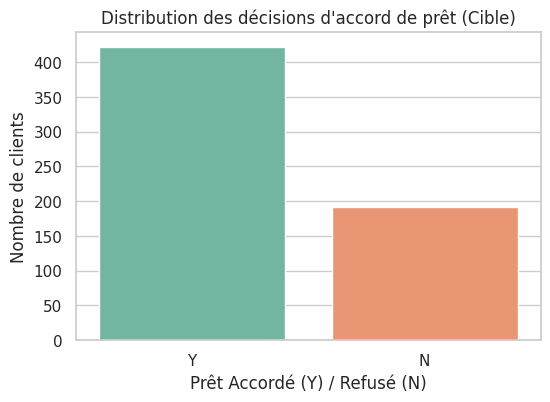

In [24]:
# Configuration du style des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


# --- VISUALISATIONS ---

# 1. Distribution de la variable cible (Loan_Status)

#Maintenant vous pouvez lancer le graphique, ça va marcher :
plt.figure(figsize=(6, 4))
sns.countplot(x='Loan_Status', data=df, palette='Set2')
plt.title("Distribution des décisions d'accord de prêt (Cible)")
plt.xlabel("Prêt Accordé (Y) / Refusé (N)")
plt.ylabel("Nombre de clients")
plt.show()

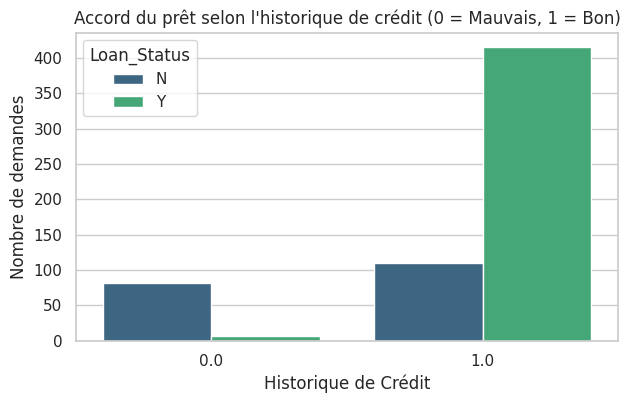

In [25]:
#  Impact crucial de l'historique de crédit (Credit_History)
# C'est généralement la variable la plus importante pour ce dataset !
plt.figure(figsize=(7, 4))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df, palette='viridis')
plt.title("Accord du prêt selon l'historique de crédit (0 = Mauvais, 1 = Bon)")
plt.xlabel("Historique de Crédit")
plt.ylabel("Nombre de demandes")
plt.savefig("2_impact_credit_history.png")
plt.show()

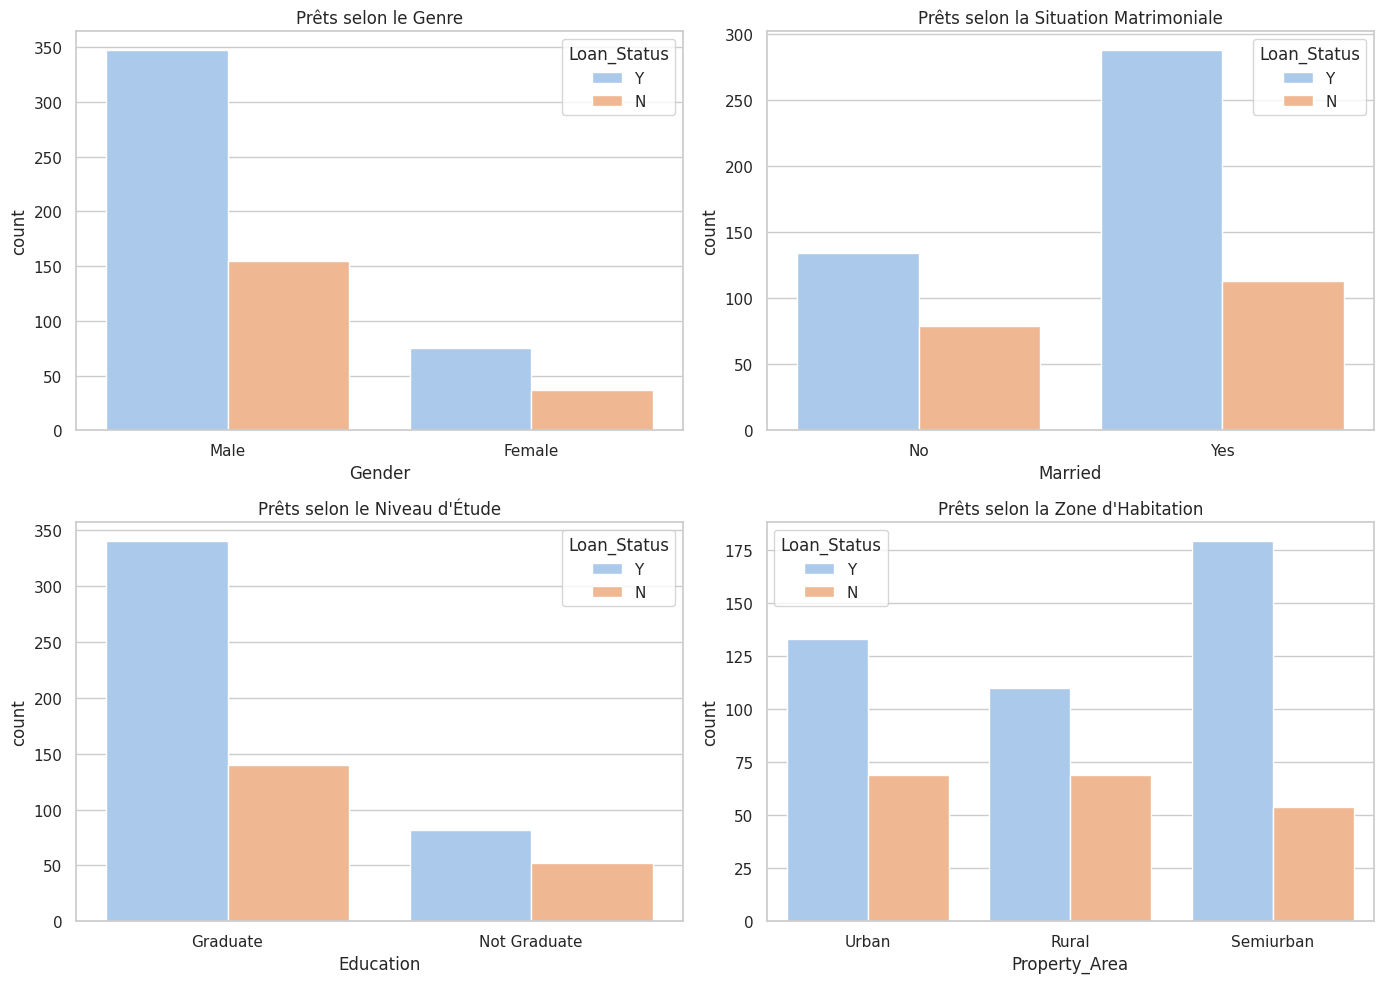

In [26]:
# Analyse des variables catégorielles (Genre, Marié, Éducation, Type de zone)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x='Gender', hue='Loan_Status', data=df, ax=axes[0,0], palette='pastel')
axes[0,0].set_title("Prêts selon le Genre")

sns.countplot(x='Married', hue='Loan_Status', data=df, ax=axes[0,1], palette='pastel')
axes[0,1].set_title("Prêts selon la Situation Matrimoniale")

sns.countplot(x='Education', hue='Loan_Status', data=df, ax=axes[1,0], palette='pastel')
axes[1,0].set_title("Prêts selon le Niveau d'Étude")

sns.countplot(x='Property_Area', hue='Loan_Status', data=df, ax=axes[1,1], palette='pastel')
axes[1,1].set_title("Prêts selon la Zone d'Habitation")

plt.tight_layout()
plt.savefig("3_variables_categoriques.png")
plt.show()

/tmp/ipykernel_2087/2308552261.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df, ax=axes[0], palette='Set3')
/tmp/ipykernel_2087/2308552261.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Status', y='LoanAmount', data=df, ax=axes[1], palette='Set3')


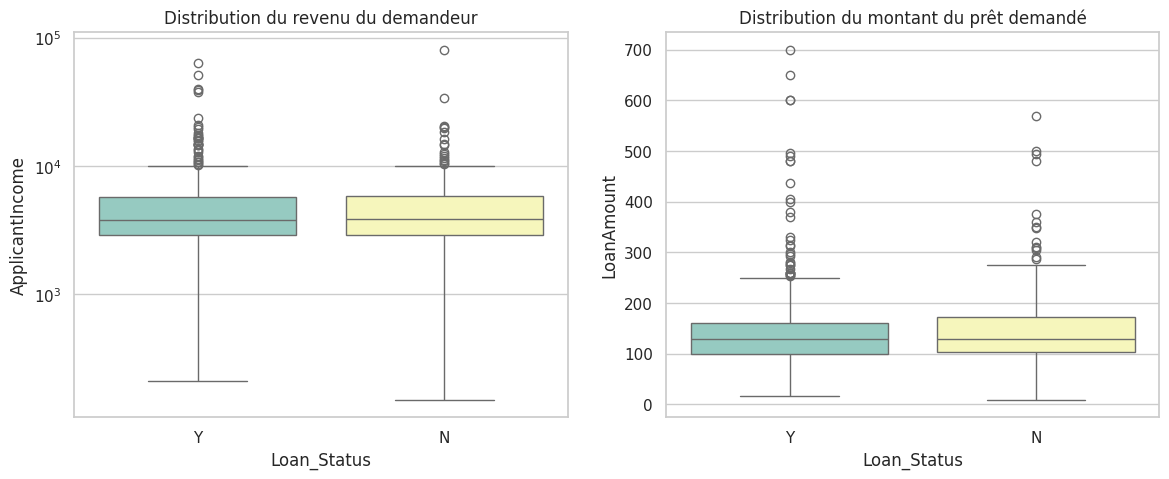

In [27]:
#  Analyse des variables numériques (Revenu et Montant du prêt)
# On utilise des boîtes à moustaches (boxplots) pour détecter les valeurs aberrantes (outliers)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df, ax=axes[0], palette='Set3')
axes[0].set_title("Distribution du revenu du demandeur")
axes[0].set_yscale('log') # Échelle logarithmique car il y a de très gros revenus (outliers)

sns.boxplot(x='Loan_Status', y='LoanAmount', data=df, ax=axes[1], palette='Set3')
axes[1].set_title("Distribution du montant du prêt demandé")

plt.savefig("4_variables_numeriques.png")
plt.show()

In [28]:
# On encode temporairement Loan_Status en 0 et 1 pour voir sa corrélation numérique de facon manuel

#df['Loan_Status_encoded'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

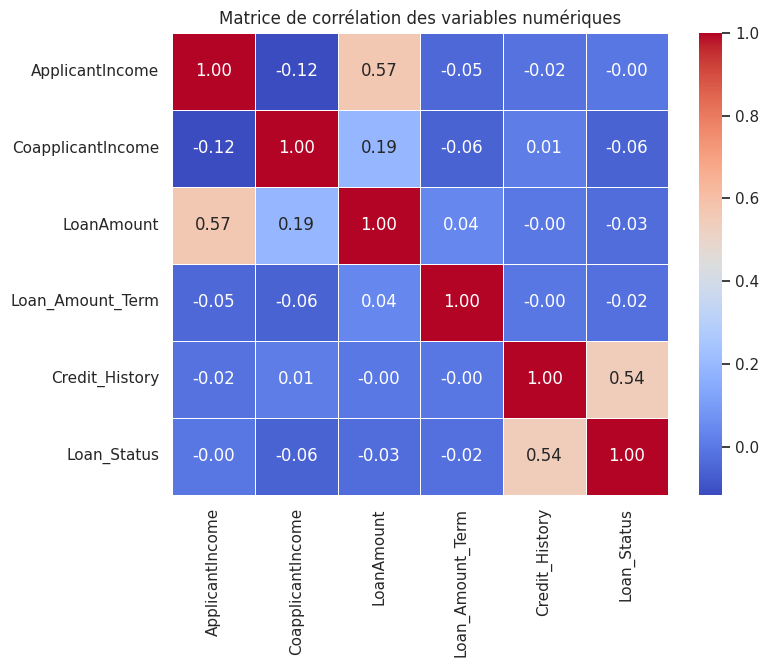

In [29]:
# Matrice de corrélation (uniquement sur les colonnes numériques)
plt.figure(figsize=(8, 6))

df_corr = df.copy()
df_corr['Loan_Status'] = df_corr['Loan_Status'].map({'Y': 1, 'N': 0})
numeric_cols = df_corr.select_dtypes(include=[np.number]).columns

sns.heatmap(df_corr[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation des variables numériques")
plt.savefig("5_matrice_correlation.png")
plt.show()

Si vous devez obligatoirement utiliser la régression linéaire dans votre projet pour ce cas bancaire, l'approche standard consiste à prédire le montant maximal du prêt (LoanAmount) auquel un client a droit, en fonction de ses revenus (ApplicantIncome).C'est le seul cas mathématiquement correct pour une régression linéaire sur votre dataset, car le montant est une valeur numérique continue.Voici le code complet, nettoyé de ses valeurs manquantes, pour entraîner votre modèle et afficher le résultat.

In [30]:
# Créer une copie indépendante du dataset
df_copie = df.copy()


In [31]:
#Feature Engineering (Très important)

# Revenu total du foyer
df['Total_Income'] = (
    df['ApplicantIncome']
    + df['CoapplicantIncome']
)

# Ratio prêt/revenu
df['Loan_Income_Ratio'] = (
    df['LoanAmount'] /
    (df['Total_Income'] + 1)
)

# Suppression des colonnes inutiles
df.drop(
    columns=['Loan_ID'],
    inplace=True
)

In [32]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Loan_Income_Ratio
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0,0.021880
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,0.021011
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0.021993
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,0.024282
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,0.023496


In [33]:
df_copie.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [34]:
# 4. Encodage des variables textuelles en valeurs numériques

#Encodage
colonnes_cat = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

encodeurs = {}

for col in colonnes_cat:
    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    encodeurs[col] = le

In [35]:

#encodeurs

In [36]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Loan_Income_Ratio
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1,5849.0,0.021880
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0,0.021011
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0,0.021993
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0,0.024282
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0,0.023496


In [37]:
# 5. Séparation des features (X) et de la cible (y)

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [38]:
# 6. Découpage Train/Test (Essentiel : stratify=y pour éviter le déséquilibre)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [39]:

# 7. Normalisation des données

#Standardisation

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)




In [40]:
#Équilibrage avec SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

In [41]:
# 8. Entraînement du modèle (Random Forest est idéal pour ce type de données)

#model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
#model.fit(X_train, y_train)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, random_state=42)

In [42]:
# 9. Prédictions et Évaluation du modèle


y_pred = model.predict(X_test)


In [43]:
#10. Evaluation

print("=== PERFORMANCES DU MODÈLE ===")
print(f"Accuracy Score (Précision globale) : {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=['Refusé (0)', 'Accordé (1)']))



=== PERFORMANCES DU MODÈLE ===
Accuracy Score (Précision globale) : 82.93%

Rapport de classification :
              precision    recall  f1-score   support

  Refusé (0)       0.73      0.71      0.72        38
 Accordé (1)       0.87      0.88      0.88        85

    accuracy                           0.83       123
   macro avg       0.80      0.80      0.80       123
weighted avg       0.83      0.83      0.83       123



In [44]:
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

Matrice de confusion :
[[27 11]
 [10 75]]


In [45]:
model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

model_xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:07:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight", "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              class_weight='balanced', colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=None, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, min_samples_leaf=2, min_samples_split=5,
              missing=nan, monotone_constraints=None, multi_strategy=None, ...)

In [46]:
y_pred_xgb = model_xgb.predict(X_test)

In [47]:
#10. Evaluation

print("=== PERFORMANCES DU MODÈLE ===")
print(f"Accuracy Score (Précision globale) : {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%\n")
print("Rapport de classification :")
print(classification_report(y_test, y_pred_xgb, target_names=['Refusé (0)', 'Accordé (1)']))



=== PERFORMANCES DU MODÈLE ===
Accuracy Score (Précision globale) : 76.42%

Rapport de classification :
              precision    recall  f1-score   support

  Refusé (0)       0.62      0.61      0.61        38
 Accordé (1)       0.83      0.84      0.83        85

    accuracy                           0.76       123
   macro avg       0.72      0.72      0.72       123
weighted avg       0.76      0.76      0.76       123



In [48]:
model_log = LogisticRegression()

model_log.fit(X_train, y_train)

LogisticRegression()

In [49]:
y_pred_log = model_log.predict(X_test)

In [50]:
#10. Evaluation

print("=== PERFORMANCES DU MODÈLE ===")
print(f"Accuracy Score (Précision globale) : {accuracy_score(y_test, y_pred_log) * 100:.2f}%\n")
print("Rapport de classification :")
print(classification_report(y_test, y_pred_log, target_names=['Refusé (0)', 'Accordé (1)']))



=== PERFORMANCES DU MODÈLE ===
Accuracy Score (Précision globale) : 82.93%

Rapport de classification :
              precision    recall  f1-score   support

  Refusé (0)       0.77      0.63      0.70        38
 Accordé (1)       0.85      0.92      0.88        85

    accuracy                           0.83       123
   macro avg       0.81      0.77      0.79       123
weighted avg       0.83      0.83      0.82       123



In [51]:
print(df['Loan_Status'].value_counts())

Loan_Status
1    422
0    192
Name: count, dtype: int64


In [52]:
# Sauvegarder le modèle de classification Random Forest
#joblib.dump(model, "random_forest_credit.pkl")
#print("Modèle Random Forest sauvegardé avec succès !")

# Sauvegarder le scaler (si vous l'avez utilisé pour harmoniser les revenus/montants)
#joblib.dump(scaler, "scaler_credit.pkl")
#print("Scaler sauvegardé !")

In [53]:
#Sauvegarde
joblib.dump(
    model,
    "modele_credit.pkl"

)

joblib.dump(
    scaler,
    "scaler_credit.pkl"

)

joblib.dump(
    X.columns.tolist(),
    "colonnes_modele.pkl"
)

joblib.dump(
    encodeurs,
    "encodeurs.pkl"
)

print("Modèle sauvegardé.")

Modèle sauvegardé.


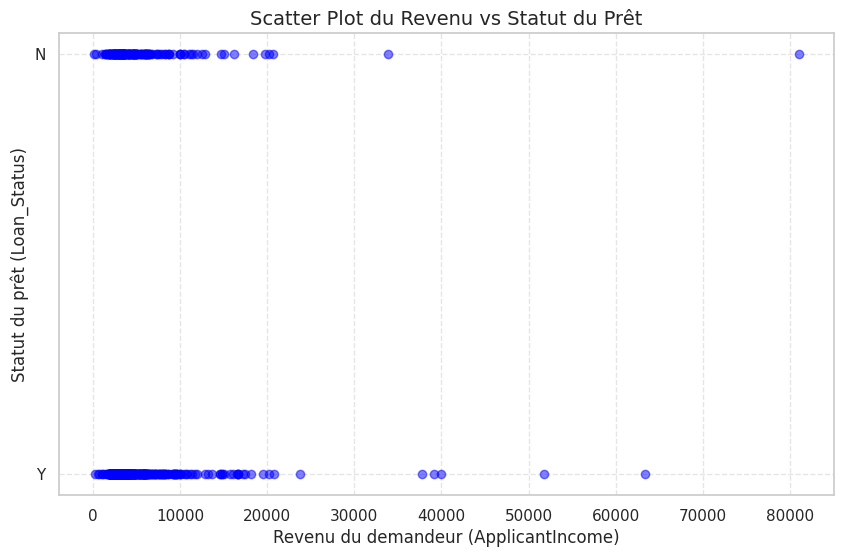

In [54]:
#import matplotlib.pyplot as plt
#import pandas as pd

# 1. On crée un dataset de travail propre sans valeurs manquantes
# pour être certain que X et y fassent la même taille
df_graph = df_copie[["ApplicantIncome", "Loan_Status"]].dropna()

# 2. On définit précisément notre X (une seule colonne) et notre y
X_graph = df_graph["ApplicantIncome"]
y_graph = df_graph["Loan_Status"]

# 3. Affichage du graphique de dispersion (Scatter Plot)
plt.figure(figsize=(10, 6))
plt.scatter(X_graph, y_graph, color="blue", alpha=0.5)

# Personnalisation des titres
plt.xlabel("Revenu du demandeur (ApplicantIncome)", fontsize=12)
plt.ylabel("Statut du prêt (Loan_Status)", fontsize=12)
plt.title("Scatter Plot du Revenu vs Statut du Prêt", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)

# Affichage final
plt.show()
